In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots
import seaborn as sns
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import FuncFormatter

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "no-latex", "grid"])

In [12]:
def plot_zoomed_delta_t(
    df_emp: pl.DataFrame, ticker: str = "PFE", drop: float = 0.5, save: bool = False
) -> tuple[float, float]:
    df_emp = df_emp.drop_nulls()
    df_emp = df_emp.with_columns(dt_log=pl.col("delta_t").log10())
    dt_log = df_emp["dt_log"].to_numpy()

    fig, ax = plt.subplots(figsize=(4, 3))

    counts, edges, patches = ax.hist(dt_log, bins=80, density=True, alpha=0.85)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # find mode and 50% drop level
    mode_idx = np.argmax(counts)
    mode_x = centers[mode_idx]
    mode_y = counts[mode_idx]
    half_y = mode_y * drop

    # find left and right crossings of 50% level
    left_cross = centers[0]
    for i in range(mode_idx, -1, -1):
        if counts[i] < half_y:
            left_cross = centers[i]
            break
    right_cross = centers[-1]
    for i in range(mode_idx, len(counts)):
        if counts[i] < half_y:
            right_cross = centers[i]
            break

    # vertical band for FWHM
    ax.axvspan(left_cross, right_cross, color="#B5121B", alpha=0.15)
    ax.axvline(
        mode_x,
        color="#B5121B",
        ls="--",
        lw=1,
        label=f"Mode $\\approx 10^{{{mode_x:.1f}}}$ ns",
    )

    ax.set_xlabel(r"$\Delta t$ in nanoseconds")
    ax.set_ylabel("Density")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$"))

    # inset zoom on [3, 5], positioned to the right and lower
    axins = ax.inset_axes([0.55, 0.35, 0.42, 0.55])
    axins.hist(dt_log, bins=80, density=True, alpha=0.85)
    axins.axvspan(left_cross, right_cross, color="#B5121B", alpha=0.15)
    axins.axvline(mode_x, color="#B5121B", ls="--", lw=1)
    axins.axhline(half_y, color="grey", ls=":", lw=0.8)

    axins.set_xlim(3, 5)
    axins.set_ylim(0, mode_y * 1.15)
    axins.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$"))
    axins.tick_params(labelsize=5.5)
    axins.set_title(
        f"50% region: [$10^{{{left_cross:.1f}}}$, $10^{{{right_cross:.1f}}}$] ns",
        fontsize=5.5,
    )

    # manual connector lines from bottom corners of inset to the zoom region
    for x_data in [3, 5]:
        con = ConnectionPatch(
            xyA=(x_data, 0),
            coordsA=axins.transData,
            xyB=(x_data, 0),
            coordsB=ax.transData,
            color="gray",
            lw=0.5,
            ls="--",
        )
        fig.add_artist(con)

    # hide the default indicate_inset_zoom box
    axins.set_zorder(10)

    ax.legend(fontsize=6.5, framealpha=0.7, edgecolor="none", loc="upper left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    if save:
        fig.savefig(f"../../paper/delta_t_zoomed_peak_{ticker}.pdf", bbox_inches="tight")
    plt.show()
    return left_cross, right_cross

In [13]:
def plot_imbalance_fast(
    df_emp: pl.DataFrame,
    left_cross: float,
    right_cross: float,
    ticker: str = "PFE",
    save: bool = False,
) -> None:
    df_emp = df_emp.drop_nulls()
    df_emp = df_emp.with_columns(dt_log=pl.col("delta_t").log10())
    df_emp = df_emp.with_columns(fast_event=pl.col("dt_log").le(right_cross))
    df_emp = df_emp.with_columns(
        delta_event=pl.col("dt_log").is_between(left_cross, right_cross)
    )

    imb_dist = (
        df_emp.filter(~pl.col("fast_event") & pl.col("event").eq("Trade"))["imbalance"]
        .value_counts(normalize=True)
        .sort("imbalance")
    )

    imb_sim = (
        df_emp.filter(pl.col("delta_event") & pl.col("event").eq("Trade"))["imbalance"]
        .value_counts(normalize=True)
        .sort("imbalance")
    )

    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    x = imb_dist["imbalance"]
    width = 0.05

    ax.bar(x, imb_dist["proportion"], width, label="Control", alpha=0.85)
    ax.bar(x + width * 3.5 / 4, imb_sim["proportion"], width, label="Fast", alpha=0.85)

    ax.set_xlabel("Imbalance Bin")
    ax.set_ylabel("Proportion")
    ax.legend()
    # ax.set_title(f"Binned imbalance distribution (before a trade) Ticker: {ticker}")
    plt.tight_layout()
    fig.savefig(
        f"../../paper/imb_distrib_before_trade_fast_events_{ticker}.pdf",
        bbox_inches="tight",
    )
    plt.show()

In [4]:
ticker = "PFE"
df, df_emp = load_data(ticker)

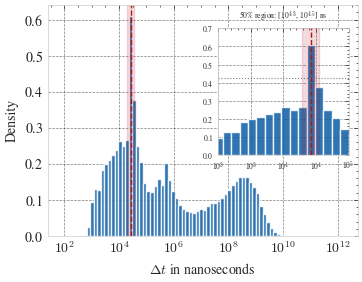

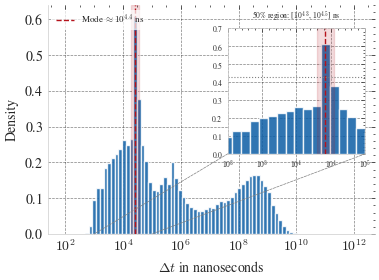

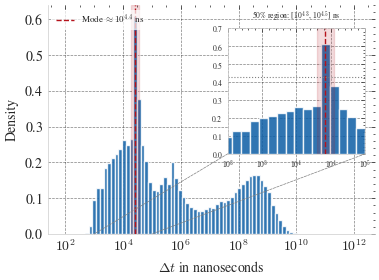

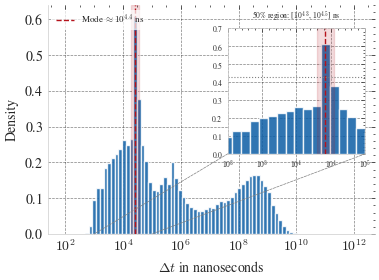

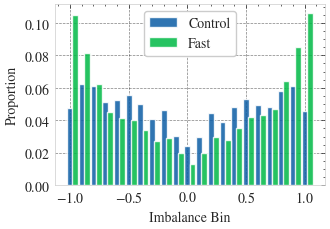

In [14]:
with transparent():
    plot_imbalance_fast(
        df_emp, *plot_zoomed_delta_t(df_emp, ticker, drop=0.7, save=True), ticker, True
    )